# Causal Explainable AI for Predictive Maintenance using NASA C-MAPSS

## Notebook 01: Data Understanding & Causal Framing of Turbofan Degradation

## Problem Definition

The objective of this project is to develop a causal and explainable AI system for predictive maintenance using the NASA C-MAPSS turbofan engine dataset.

Unlike traditional predictive models that only forecast failure, this study aims to:
- Identify degradation patterns in engine sensor data
- Understand relationships between operational settings and failure progression
- Build a foundation for causal reasoning in machine health monitoring

## Dataset Overview

NASA C-MAPSS contains multi-cycle engine degradation data with:
- engine_id (machine unit)
- cycle (time step)
- operational settings (environment conditions)
- 21 sensor measurements (health indicators)


## Why This Dataset is Suitable for Causal AI

This dataset is ideal for causal analysis because:

- It represents temporal machine degradation
- Multiple interacting operational variables exist
- Sensor outputs evolve over time under changing conditions
- Failure is not instantaneous but progressive

This allows exploration beyond prediction into causal structure discovery.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
from google.colab import files

uploaded = files.upload()

Saving train_FD001.txt to train_FD001.txt


In [3]:
columns = [
    "engine_id",
    "cycle",
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3"
]

# Add sensor names
for i in range(1,22):
    columns.append(f"sensor_{i}")

len(columns)

26

In [4]:
train_path = "train_FD001.txt"  # ensure file is in working directory or Colab upload

df = pd.read_csv(
    train_path,
    sep="\s+",
    header=None
)

# Remove empty columns caused by spacing
df = df.dropna(axis=1)

# Assign column names
df.columns = columns

df.head()

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1874/4057098650.py:5: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
print("Dataset shape:")
print(df.shape)

Dataset shape:
(20631, 26)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   engine_id              20631 non-null  int64  
 1   cycle                  20631 non-null  int64  
 2   operational_setting_1  20631 non-null  float64
 3   operational_setting_2  20631 non-null  float64
 4   operational_setting_3  20631 non-null  float64
 5   sensor_1               20631 non-null  float64
 6   sensor_2               20631 non-null  float64
 7   sensor_3               20631 non-null  float64
 8   sensor_4               20631 non-null  float64
 9   sensor_5               20631 non-null  float64
 10  sensor_6               20631 non-null  float64
 11  sensor_7               20631 non-null  float64
 12  sensor_8               20631 non-null  float64
 13  sensor_9               20631 non-null  float64
 14  sensor_10              20631 non-null  float64
 15  se

In [7]:
df.describe()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.300000e+00,47.541168,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,0.001389,0.885092,0.070985,22.082880,4.660829e-13,0.267087,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.300000e+00,46.850000,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.300000e+00,47.350000,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.300000e+00,47.510000,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.300000e+00,47.700000,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.300000e+00,48.530000,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [8]:
number_of_engines = df["engine_id"].nunique()

print("Number of engines:", number_of_engines)

Number of engines: 100


In [9]:
engine_life = df.groupby("engine_id")["cycle"].max()

engine_life.head()

,cycle
engine_id,
1,192
2,287
3,179
4,189
5,269


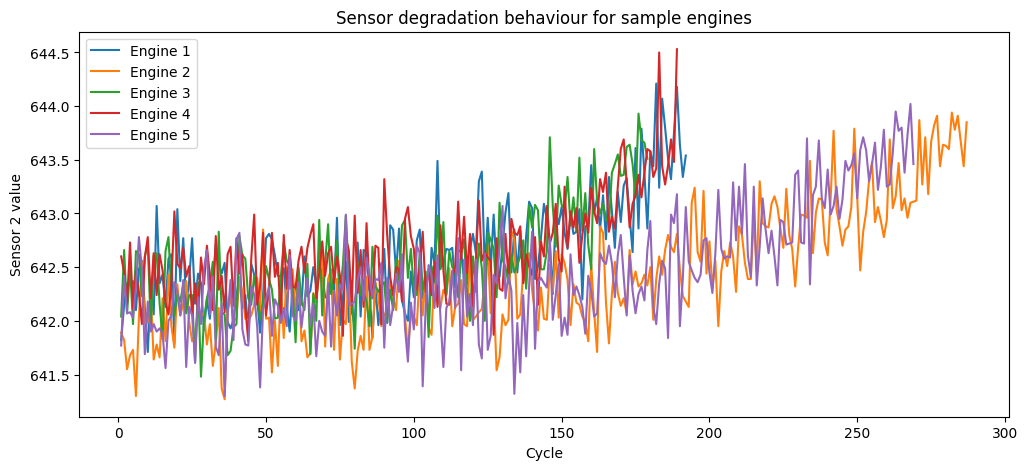

In [10]:
plt.figure(figsize=(12,5))

for engine in range(1,6):

    engine_data = df[df["engine_id"] == engine]

    plt.plot(
        engine_data["cycle"],
        engine_data["sensor_2"],
        label=f"Engine {engine}"
    )


plt.xlabel("Cycle")
plt.ylabel("Sensor 2 value")

plt.title(
    "Sensor degradation behaviour for sample engines"
)

plt.legend()

plt.show()

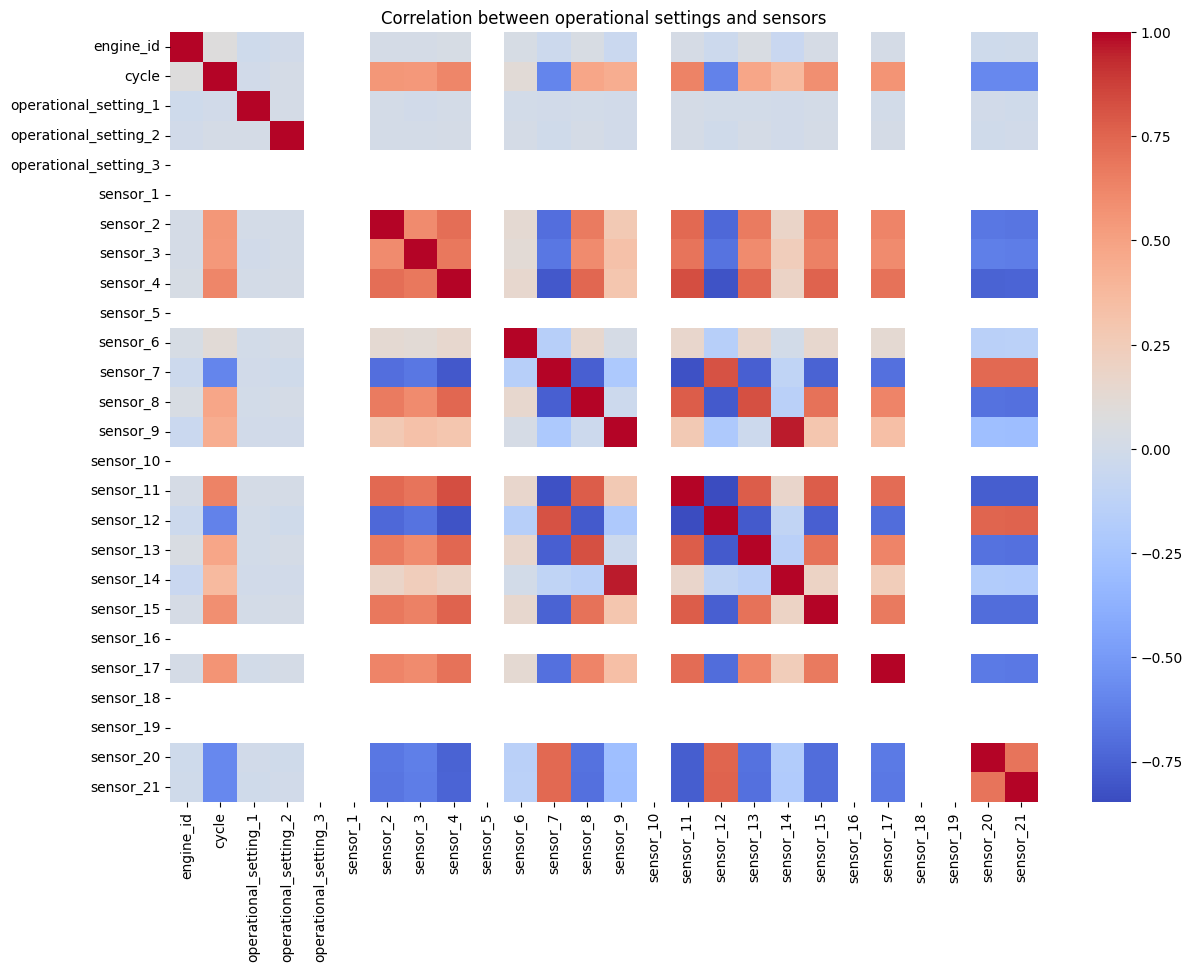

In [11]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title(
    "Correlation between operational settings and sensors"
)

plt.show()

## Key Observations

- Engines show clear degradation patterns across operational cycles
- Sensor readings exhibit both stable and drifting behavior over time
- Operational settings influence variability in sensor responses
- Strong correlations exist between certain sensors, suggesting shared system dependencies

These patterns indicate potential hidden causal relationships that cannot be captured through correlation alone, motivating causal AI methods in later notebooks.